In [ ]:
#========================================================================
# Name: plot_fig_S2_ctt_CDFs.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
#
# Description: Plot cumulative distribution functions of cloud-top
#              temperature for WRF and observations.
#========================================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime
import dask
from dask.distributed import wait
from distributed import Client, LocalCluster
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [2]:
iparallel = True

In [3]:
if iparallel:
    dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 
    cluster = LocalCluster(n_workers=100,threads_per_worker=1)
    client = Client(cluster)

2025-10-28 20:04:17,533 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2025-10-28 20:04:21,894 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2025-10-28 20:04:28,689 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2025-10-28 20:05:02,255 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2025-10-28 20:05:05,518 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2025-10-28 20:05:12,513 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2025-10-28 20:05:17,804 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2025-10-28 20:05:25,798 - distributed.utils_perf - WARNING - full garbage collections took

In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Workers: 100
Total threads: 100,Total memory: 476.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44079,Workers: 100
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Total threads: 100
Started: Just now,Total memory: 476.37 GiB
Comm: tcp://127.0.0.1:39345,Total threads: 1
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:42253/status,Memory: 4.76 GiB
Nanny: tcp://127.0.0.1:45167,


In [67]:
path = '/pscratch/sd/m/mckenna/cacti/wrf/derived_3km/'
files = sorted(glob.glob(path+'WRF_CACTI_3km_derived_*.nc'))#[::4]
num_files = len(files)
print('# of files:',num_files)

# of files: 8794


In [66]:
#files[0:4]

In [6]:
#ds = xr.open_dataset(files[0])
#print(list(ds.keys()))
#ds.close()

['col_max_ref', 'ir_tb', 'lwp', 'iwp', 'twp', 'ctt_thresh_1', 'ctt_thresh_2', 'ctt_thresh_3', 'cth_thresh_1', 'cth_thresh_2', 'cth_thresh_3', 'ctt_tau_vis', 'cth_tau_vis', 'ctt_tau_ir', 'cth_tau_ir', 'ctt_tau_10_90', 'cth_tau_10_90', 'ctt_tau_30_70', 'cth_tau_30_70', 'ctt_tau_50_50', 'cth_tau_50_50', 'ctt_tau_70_30', 'cth_tau_70_30', 'ctt_tau_90_10', 'cth_tau_90_10', 'opd_vis', 'opd_ir', 'opd_10_90', 'opd_30_70', 'opd_50_50', 'opd_70_30', 'opd_90_10']


In [68]:
def preprocess(ds_single):
    # subset variables
    keep_vars = [
        'ctt_thresh_1','ctt_thresh_2','ctt_thresh_3',
        'ctt_tau_vis','ctt_tau_ir',
        'ctt_tau_10_90','ctt_tau_30_70','ctt_tau_50_50',
        'ctt_tau_70_30','ctt_tau_90_10',
        'col_max_ref','ir_tb','twp',
    ]
    ds_single = ds_single[keep_vars]
    
    # convert epoch time to datetime64 for consistent concat
    if 'time' in ds_single.coords:
        ds_single['time'] = xr.decode_cf(ds_single).time
    
    return ds_single

In [69]:
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    chunks={'time': 1},
    preprocess=preprocess
)
ds = ds.sortby('time')

In [70]:
#ds

In [71]:
vars_to_use = [
    'ctt_thresh_1','ctt_thresh_2','ctt_thresh_3',
    'ctt_tau_vis','ctt_tau_ir',
    'ctt_tau_10_90','ctt_tau_30_70','ctt_tau_50_50',
    'ctt_tau_70_30','ctt_tau_90_10','ir_tb','twp'
]

cdf_dict = {}
for var in vars_to_use:
    if var == 'ir_tb':
        data = ds[var].values.flatten()-273.15           # flatten to 1D
        #anc_data = ds['ctt_thresh_1'].values.flatten()
        anc_data = ds['twp'].values.flatten()*1.e3 # convert from kg/m^2 to g/m^2
        data[(anc_data <= 1.e-3) | (np.isnan(anc_data))] = np.nan
    else:
        data = ds[var].values.flatten()           # flatten to 1D
    data = data[~np.isnan(data)]             # remove NaNs
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    cdf_dict[var] = {'x': sorted_data, 'cdf': cdf}

2025-10-28 20:52:40,295 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2025-10-28 20:53:24,269 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2025-10-28 20:54:07,844 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2025-10-28 20:54:50,047 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)


In [72]:
#print(np.nanmax(ds['twp'].values))
#print(np.nanmin(ds['twp'].values[ds['twp'].values > 0.]))
#print(np.nanmax(ds_obs['lwp_iwp'].values))
#print(np.nanmin(ds_obs['lwp_iwp'].values))

In [73]:
cdf_file = "ctt_cdfs_subset.pkl"
save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_cdfs/'
with open(save_path+cdf_file, "wb") as f:
    pickle.dump(cdf_dict, f)
print(f"CDFs saved to {cdf_file}")

CDFs saved to ctt_cdfs_subset.pkl


In [3]:
cdf_file = "ctt_cdfs_subset.pkl"
in_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_cdfs/'
with open(in_path+cdf_file, "rb") as f:
    cdf_dict = pickle.load(f)

In [75]:
plt.rcParams['text.usetex'] = True

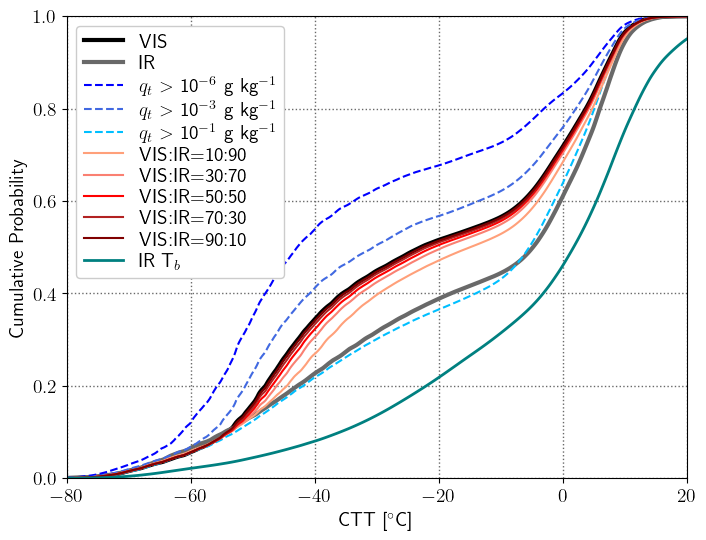

done


In [76]:
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
Fontsize=14
axlist = [ax1]
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
    ax.set_ylabel('Cumulative Probability',fontsize=Fontsize)

ax1.plot(cdf_dict['ctt_tau_vis']['x'],cdf_dict['ctt_tau_vis']['cdf'],label='VIS',lw=3,ls='solid',c='k')
ax1.plot(cdf_dict['ctt_tau_ir']['x'],cdf_dict['ctt_tau_ir']['cdf'],label='IR',lw=3,ls='solid',c='dimgrey')
ax1.plot(cdf_dict['ctt_thresh_1']['x'],cdf_dict['ctt_thresh_1']['cdf'],label='$q_{t}$ $>$ 10$^{-6}$ g kg$^{-1}$',lw=1.5,ls='dashed',c='blue')
ax1.plot(cdf_dict['ctt_thresh_2']['x'],cdf_dict['ctt_thresh_2']['cdf'],label='$q_{t}$ $>$ 10$^{-3}$ g kg$^{-1}$',lw=1.5,ls='dashed',c='royalblue')
ax1.plot(cdf_dict['ctt_thresh_3']['x'],cdf_dict['ctt_thresh_3']['cdf'],label='$q_{t}$ $>$ 10$^{-1}$ g kg$^{-1}$',lw=1.5,ls='dashed',c='deepskyblue')
ax1.plot(cdf_dict['ctt_tau_10_90']['x'],cdf_dict['ctt_tau_10_90']['cdf'],label='VIS:IR=10:90',lw=1.5,ls='solid',c='lightsalmon')
ax1.plot(cdf_dict['ctt_tau_30_70']['x'],cdf_dict['ctt_tau_30_70']['cdf'],label='VIS:IR=30:70',lw=1.5,ls='solid',c='salmon')
ax1.plot(cdf_dict['ctt_tau_50_50']['x'],cdf_dict['ctt_tau_50_50']['cdf'],label='VIS:IR=50:50',lw=1.5,ls='solid',c='red')
ax1.plot(cdf_dict['ctt_tau_70_30']['x'],cdf_dict['ctt_tau_70_30']['cdf'],label='VIS:IR=70:30',lw=1.5,ls='solid',c='firebrick')
ax1.plot(cdf_dict['ctt_tau_90_10']['x'],cdf_dict['ctt_tau_90_10']['cdf'],label='VIS:IR=90:10',lw=1.5,ls='solid',c='maroon')
ax1.plot(cdf_dict['ir_tb']['x'],cdf_dict['ir_tb']['cdf'],label='IR T$_{b}$',lw=2,ls='solid',c='teal')

leg = ax.legend(loc='upper left',fontsize=Fontsize,framealpha=True,labelspacing=0.2)

ax1.set_xlim(-80,20)
ax1.set_ylim(0,1)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'ctt_cdfs.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')

In [4]:
# Compute medians directly from CDF arrays
median_vis = np.nanpercentile(cdf_dict['ctt_tau_vis']['x'], 50)
median_modest = np.nanpercentile(cdf_dict['ctt_thresh_2']['x'], 50)
median_50vis = np.nanpercentile(cdf_dict['ctt_tau_50_50']['x'], 50)
median_ir = np.nanpercentile(cdf_dict['ctt_tau_ir']['x'], 50)
median_strict = np.nanpercentile(cdf_dict['ctt_thresh_3']['x'], 50)
median_ir_tb = np.nanpercentile(cdf_dict['ir_tb']['x'], 50)

print("VIS - modest threshold:", median_vis - median_modest)
print("50-50 weighting - VIS:", median_50vis - median_vis)
print("VIS - IR:", median_vis - median_ir)
print("IR - strict threshold:", median_ir - median_strict)
print("IR - IR Tb:", median_ir - median_ir_tb)
print("IR - 

VIS - modest threshold: 7.646211242675804
50-50 weighting - VIS: 2.0553207397460938
VIS - IR: -18.09113311767578
IR - strict threshold: 0.6079193115234602
IR - IR Tb: -6.553182983398415


In [5]:
obs_path = '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/'
obs_files = sorted(glob.glob(obs_path+'*_v2.nc'))
num_obs_files = len(obs_files)
print(num_obs_files)

100


In [6]:
def preprocess_obs(ds_single):
    # subset variables
    keep_vars = [
        'ir_tb','ctt','lwp_iwp',
    ]
    ds_single = ds_single[keep_vars]
    
    # convert epoch time to datetime64 for consistent concat
    if 'time' in ds_single.coords:
        ds_single['time'] = xr.decode_cf(ds_single).time
    
    return ds_single

In [7]:
ds_obs = xr.open_mfdataset(
    obs_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    #chunks={'time': 1},
    preprocess=preprocess_obs
)
ds_obs = ds_obs.sortby('time')

In [8]:
obs_vars_to_use = [
        'ir_tb','ctt','lwp_iwp'
]

obs_cdf_dict = {}
for var in obs_vars_to_use:
    if var == 'ir_tb':
        data = ds_obs[var].values.flatten()          # flatten to 1D
        anc_data = ds_obs['lwp_iwp'].values.flatten()
        #data[np.isnan(anc_data)] = np.nan
        data[(anc_data <= 1.e-3) | (np.isnan(anc_data))] = np.nan
        print(np.nanmin(anc_data))
        print(np.nanmax(anc_data))
    else:
        data = ds_obs[var].values.flatten()           # flatten to 1D
    data = data[~np.isnan(data)]             # remove NaNs
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    obs_cdf_dict[var] = {'x': sorted_data, 'cdf': cdf}

3.364563e-05
6000.0


In [10]:
# Compute medians directly from CDF arrays
median_vis = np.nanpercentile(cdf_dict['ctt_tau_vis']['x'], 50)
median_modest = np.nanpercentile(cdf_dict['ctt_thresh_2']['x'], 50)
median_50vis = np.nanpercentile(cdf_dict['ctt_tau_50_50']['x'], 50)
median_ir = np.nanpercentile(cdf_dict['ctt_tau_ir']['x'], 50)
median_strict = np.nanpercentile(cdf_dict['ctt_thresh_3']['x'], 50)
median_ir_tb = np.nanpercentile(cdf_dict['ir_tb']['x'], 50)
median_obs_ctt = np.nanpercentile(obs_cdf_dict['ctt']['x'], 50)

print("VIS - modest threshold:", median_vis - median_modest)
print("50-50 weighting - VIS:", median_50vis - median_vis)
print("VIS - IR:", median_vis - median_ir)
print("IR - strict threshold:", median_ir - median_strict)
print("IR - IR Tb:", median_ir - median_ir_tb)
print("Obs CTT - IR:",median_obs_ctt - median_ir) 

VIS - modest threshold: 7.646211242675804
50-50 weighting - VIS: 2.0553207397460938
VIS - IR: -18.09113311767578
IR - strict threshold: 0.6079193115234602
IR - IR Tb: -6.553182983398415
Obs CTT - IR: -0.10863647460939774


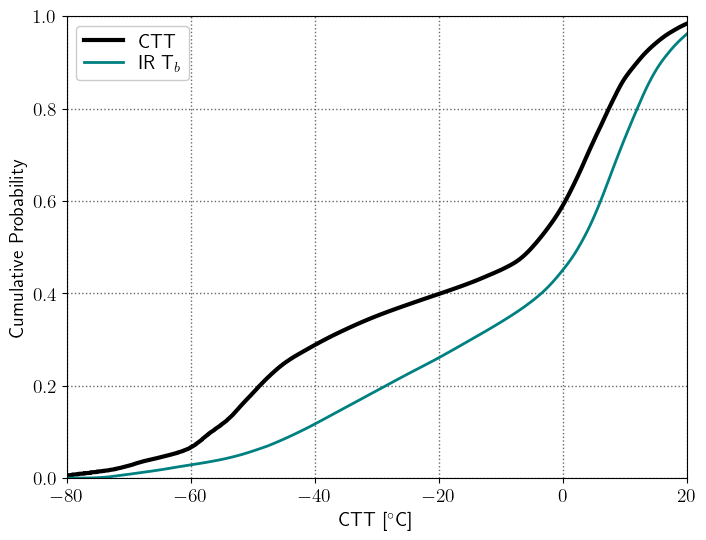

done


In [82]:
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
Fontsize=14
axlist = [ax1]
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
    ax.set_ylabel('Cumulative Probability',fontsize=Fontsize)

ax1.plot(obs_cdf_dict['ctt']['x'],obs_cdf_dict['ctt']['cdf'],label='CTT',lw=3,ls='solid',c='k')
ax1.plot(obs_cdf_dict['ir_tb']['x'],obs_cdf_dict['ir_tb']['cdf'],label='IR T$_{b}$',lw=2,ls='solid',c='teal')

leg = ax.legend(loc='upper left',fontsize=Fontsize,framealpha=True,labelspacing=0.2)

ax1.set_xlim(-80,20)
ax1.set_ylim(0,1)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'obs_ctt_cdfs.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')

In [84]:
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)
Fontsize=14
axlist = [ax1]
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('CTT [$^{\\circ}$C]',fontsize=Fontsize)
    ax.set_ylabel('Cumulative Probability',fontsize=Fontsize)

ax1.plot(cdf_dict['ctt_tau_vis']['x'],cdf_dict['ctt_tau_vis']['cdf'],label='VIS',lw=3,ls='solid',c='k')
ax1.plot(cdf_dict['ctt_tau_ir']['x'],cdf_dict['ctt_tau_ir']['cdf'],label='IR',lw=3,ls='solid',c='dimgrey')
ax1.plot(cdf_dict['ctt_thresh_1']['x'],cdf_dict['ctt_thresh_1']['cdf'],label='$q_{t}$ $>$ 10$^{-6}$ g kg$^{-1}$',lw=1.5,ls='dashed',c='blue')
ax1.plot(cdf_dict['ctt_thresh_2']['x'],cdf_dict['ctt_thresh_2']['cdf'],label='$q_{t}$ $>$ 10$^{-3}$ g kg$^{-1}$',lw=1.5,ls='dashed',c='royalblue')
ax1.plot(cdf_dict['ctt_thresh_3']['x'],cdf_dict['ctt_thresh_3']['cdf'],label='$q_{t}$ $>$ 10$^{-1}$ g kg$^{-1}$',lw=1.5,ls='dashed',c='deepskyblue')
ax1.plot(cdf_dict['ctt_tau_10_90']['x'],cdf_dict['ctt_tau_10_90']['cdf'],label='VIS:IR=10:90',lw=1.5,ls='solid',c='lightsalmon')
ax1.plot(cdf_dict['ctt_tau_30_70']['x'],cdf_dict['ctt_tau_30_70']['cdf'],label='VIS:IR=30:70',lw=1.5,ls='solid',c='salmon')
ax1.plot(cdf_dict['ctt_tau_50_50']['x'],cdf_dict['ctt_tau_50_50']['cdf'],label='VIS:IR=50:50',lw=1.5,ls='solid',c='red')
ax1.plot(cdf_dict['ctt_tau_70_30']['x'],cdf_dict['ctt_tau_70_30']['cdf'],label='VIS:IR=70:30',lw=1.5,ls='solid',c='firebrick')
ax1.plot(cdf_dict['ctt_tau_90_10']['x'],cdf_dict['ctt_tau_90_10']['cdf'],label='VIS:IR=90:10',lw=1.5,ls='solid',c='maroon')
ax1.plot(cdf_dict['ir_tb']['x'],cdf_dict['ir_tb']['cdf'],label='IR T$_{b}$',lw=2,ls='solid',c='teal')

ax1.plot(obs_cdf_dict['ctt']['x'],obs_cdf_dict['ctt']['cdf'],label='Obs. CTT',lw=2,ls='dotted',c='k')
ax1.plot(obs_cdf_dict['ir_tb']['x'],obs_cdf_dict['ir_tb']['cdf'],label='Obs. IR T$_{b}$',lw=2,ls='dotted',c='teal')

leg = ax.legend(loc='upper left',fontsize=Fontsize*0.9,framealpha=True,labelspacing=0.2,ncol=1)

ax1.set_xlim(-80,20)
ax1.set_ylim(0,1)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'ctt_obs_wrf_cdfs.png'
plt.savefig(save_path+file_name,dpi=300)
#plt.show()
plt.close()
print('done')

done


In [ ]:
ds.close()
import gc; gc.collect()
client.restart()  # optional but ideal